In [1]:
import os
import fipy as fp
import argparse
import Protein_RPA.utils.free_energy as f_en
import Protein_RPA.utils.free_energy_2comp as f_en2
from Protein_RPA import seq_list as sl
import initial_density as density
import chempot_table as chempot
import numpy as np
from Protein_RPA.utils.input_parse import input_parse
import pickle
from density_class import initial_density
import chempot_table as chempot #very similar inputs as main DDFT function

Okay relevant imports are accounted for, inputting and formatting parameters.

In [2]:
input_parameters = input_parse("./input_params.txt")
seq_name1 = input_parameters['seq_name1']  # should be part of input_parameters
seq_name2 = input_parameters['seq_name2']
no_comps = input_parameters['no_comps']

#finally, a list of input parameters for args
ehs10=input_parameters['enthalpy1']
ehs11=input_parameters['entropy1']
ehs1=np.array([ehs10, ehs11])
ef=False
if (no_comps == 2):
    ehs20=input_parameters['enthalpy2']
    ehs21=input_parameters['entropy2']
    ehs2=np.array([ehs20, ehs21])
    sig1, N1, the_seq1 = sl.get_the_charge(seq_name1)
    sig2, N2, the_seq2 = sl.get_the_charge(seq_name2)
    HP1=f_en2.RPAFH(sig1, ehs=ehs1, epsfun=ef)
    HP2=f_en2.RPAFH(sig2, ehs=ehs2, epsfun=ef)
    HP12=f_en2.RPAFH_12(sig1, sig2)
    HP = [HP1,HP2,HP12]
    FE=f_en2.free_energy(HP)
else:
    sig1, N, the_seq = sl.get_the_charge(seq_name1)
    HP = f_en.RPAFH(sig1, ehs=ehs1, epsfun=ef)
    FE=f_en.free_energy(HP)

In [3]:
print(len(HP[2]['sig1'])," ",len(HP[2]['sig2']))

286   286


In [15]:
phi1 = np.linspace(0.001,0.2,25)
phi2 = np.linspace(0.001,0.2,25)
fen_table=np.empty([len(phi1),len(phi2)])
if (len(sig2) > len(sig1)):
            zeroes = np.zeros((len(sig2)-len(sig1)))
            sig1=np.concatenate((sig1,zeroes),axis=0)
elif (len(sig2) < len(sig1)):
            zeroes = np.zeros((len(sig1)-len(sig2)))
            sig2=np.concatenate((sig2,zeroes),axis=0) 
Gamma = np.linalg.norm((sig1-sig2),1)/np.mean((np.linalg.norm(sig1,1),np.linalg.norm(sig2,1)))
for i in range(len(phi1)):
    for j in range(len(phi2)):
        fen_table[i,j]=FE.feng(phi1[i],phi2[j],0,4)

/project/zerze/morganmurray/software/RPA_ddft3_2/scripts/DDFT/Protein_RPA/utils/free_energy_2comp.py:181: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  f1 = sci.quad(self.fel1_toint1, 0, np.inf, args=(phi1,phis,u), limit=self.intlim)[0]
/project/zerze/morganmurray/software/RPA_ddft3_2/scripts/DDFT/Protein_RPA/utils/free_energy_2comp.py:182: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  f2 = sci.quad(self.fel1_toint2, 0, np.inf, args=(phi1,phis,u), limit=self.intlim)[0]
/project/zerze/morganmurray/software/RPA_ddft3_2/scripts/DDFT/Protein_RPA/utils/free_energy_2comp.py:329: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  f1 = sci.quad(self.fel12_toint1, 0, np.inf, args=(phi1,phi2,u), limit=self.intlim)[0]
/project/zerze/morganmurray/software/RPA_ddft3_2/scripts/DDFT/Protein_RPA/utils/free_energy_2comp.py:330: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  

-0.0017011432061946898   -0.31397734838207947
1.9130434782608696


<function matplotlib.pyplot.show(close=None, block=None)>

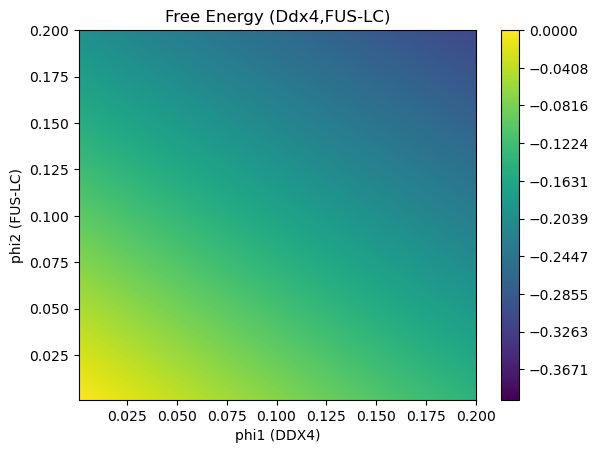

In [20]:
import matplotlib.pyplot as plt

print(np.max(fen_table), " ",np.min(fen_table) )
Gamma = np.linalg.norm((sig1-sig2),1)/np.mean((np.linalg.norm(sig1,1),np.linalg.norm(sig2,1)))
print(Gamma)
fig, ax  =plt.subplots()
cs =  ax.contourf(phi1,phi2,fen_table,np.linspace(-0.4,0,256))
fig.colorbar(cs)
ax.set_xlabel('phi1 (DDX4)')
ax.set_ylabel('phi2 (FUS-LC)')
plt.title("Free Energy (Ddx4,FUS-LC)")
#ax.legend(title='Fel')
plt.show

In [6]:
sig3 = [-1, 1, 0, 0, 0,0, 0, 0, 0, 0, 0, 0, 1, -1]
if (len(sig2) > len(sig3)):
    zeroes = np.zeros((len(sig2)-len(sig3)))
    sig3=np.concatenate((sig3,zeroes),axis=0)
elif (len(sig2) < len(sig3)):
    zeroes = np.zeros((len(sig3)-len(sig2)))
    sig2=np.concatenate((sig2,zeroes),axis=0)
print(sig3)
Gamma = np.linalg.norm((sig1-sig2),1)/np.mean((np.linalg.norm(sig1,1)+np.linalg.norm(sig2,1)))
print(Gamma)

[-1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1. -1.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0